In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("../data/processed_data/train.csv")

test_df = pd.read_csv("../data/processed_data/test.csv")

In [2]:
train_df.head()

,time,cog,sog,rot,heading,navstat,etaRaw,latitude,longitude,vesselId,...,vesselType_14.0,vesselType_21.0,vesselType_83.0,enginePower,CEU,GT,breadth,length,DWT,maxSpeed
0,0.031663,0.858217,17.1,-6,316,0,01-08 06:00,7.50361,77.58340,61e9f38eb937134a3c4bfd8b,...,False,False,True,0.365826,0.764706,0.545107,0.583333,0.505354,0.170524,0.287879
1,0.031707,0.856825,17.3,5,313,0,01-14 23:30,7.57302,77.49505,61e9f38eb937134a3c4bfd8b,...,False,False,True,0.365826,0.764706,0.545107,0.583333,0.505354,0.170524,0.287879
2,0.031757,0.854596,16.9,5,312,0,01-14 23:30,7.65043,77.39404,61e9f38eb937134a3c4bfd8b,...,False,False,True,0.365826,0.764706,0.545107,0.583333,0.505354,0.170524,0.287879
3,0.031798,0.857660,16.9,6,313,0,01-14 23:30,7.71275,77.31394,61e9f38eb937134a3c4bfd8b,...,False,False,True,0.365826,0.764706,0.545107,0.583333,0.505354,0.170524,0.287879
4,0.031838,0.855153,16.3,7,313,0,01-14 23:30,7.77191,77.23585,61e9f38eb937134a3c4bfd8b,...,False,False,True,0.365826,0.764706,0.545107,0.583333,0.505354,0.170524,0.287879


In [3]:
test_df.columns

Index(['ID', 'vesselId', 'time', 'scaling_factor', 'port_lat', 'port_long',
       'month_of_the_year', 'week_of_the_year', 'day_of_the_year',
       'day_of_the_month', 'day_of_the_week', 'hour_of_the_day',
       'hours_passed', 'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos',
       'time_diff_gt_10min', 'time_diff_gt_20min', 'time_diff_gt_40min',
       'time_diff_gt_1hour', 'time_diff_gt_2hours', 'time_diff_gt_6hours',
       'time_diff_gt_12hours', 'time_diff_gt_1day', 'avg_lat_change_1_steps',
       'avg_lon_change_1_steps', 'avg_lat_change_2_steps',
       'avg_lon_change_2_steps', 'avg_lat_change_3_steps',
       'avg_lon_change_3_steps', 'avg_lat_change_4_steps',
       'avg_lon_change_4_steps', 'avg_lat_change_5_steps',
       'avg_lon_change_5_steps', 'vesselType_14.0', 'vesselType_21.0',
       'vesselType_83.0', 'enginePower', 'CEU', 'GT', 'breadth', 'length',
       'DWT', 'maxSpeed'],
      dtype='object')

In [4]:
train_df.columns

Index(['time', 'cog', 'sog', 'rot', 'heading', 'navstat', 'etaRaw', 'latitude',
       'longitude', 'vesselId', 'portId', 'latitude_1_steps_ago',
       'longitude_1_steps_ago', 'time_position_1_steps_ago',
       'latitude_2_steps_ago', 'longitude_2_steps_ago',
       'time_position_2_steps_ago', 'latitude_3_steps_ago',
       'longitude_3_steps_ago', 'time_position_3_steps_ago',
       'latitude_4_steps_ago', 'longitude_4_steps_ago',
       'time_position_4_steps_ago', 'latitude_5_steps_ago',
       'longitude_5_steps_ago', 'time_position_5_steps_ago',
       'max_lat_change_last_5_steps', 'min_lat_change_last_5_steps',
       'max_long_change_last_5_steps', 'min_long_change_last_5_steps',
       'cog_1_step_ago', 'time_cog_1_step_ago', 'cog_2_steps_ago',
       'time_cog_2_steps_ago', 'hours_passed', 'hour_sin', 'hour_cos',
       'minute_sin', 'minute_cos', 'month_of_the_year', 'week_of_the_year',
       'day_of_the_year', 'day_of_the_month', 'day_of_the_week',
       'hour_of_the_

In [5]:
nan_counts = train_df.isna().sum()

print(nan_counts)

time        0
cog         0
sog         0
rot         0
heading     0
           ..
GT          0
breadth     0
length      0
DWT         0
maxSpeed    0
Length: 77, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split


X = train_df[['time', 'latitude_1_steps_ago',
              'port_lat', 'port_long',
       'longitude_1_steps_ago', 'time_position_1_steps_ago',
       'latitude_2_steps_ago', 'longitude_2_steps_ago',
       'time_position_2_steps_ago', 'latitude_3_steps_ago',
       'longitude_3_steps_ago', 'time_position_3_steps_ago',
       'latitude_4_steps_ago', 'longitude_4_steps_ago',
       'time_position_4_steps_ago', 'latitude_5_steps_ago',
       'longitude_5_steps_ago', 'time_position_5_steps_ago',
       'max_lat_change_last_5_steps', 'min_lat_change_last_5_steps',
       'max_long_change_last_5_steps', 'min_long_change_last_5_steps',
       'cog_1_step_ago', 'time_cog_1_step_ago', 'cog_2_steps_ago',
       'time_cog_2_steps_ago', 'hours_passed', 'hour_sin', 'hour_cos',
       'minute_sin', 'minute_cos', 'week_of_the_year', 'day_of_the_year',
       'time_diff_gt_10min', 'time_diff_gt_20min', 'time_diff_gt_40min',
       'time_diff_gt_1hour', 'time_diff_gt_2hours', 'time_diff_gt_6hours',
       'time_diff_gt_12hours', 'time_diff_gt_1day', 'lat_change_2_to_1_steps',
       'lat_change_3_to_2_steps', 'lat_change_4_to_3_steps',
       'lat_change_5_to_4_steps', 'lon_change_2_to_1_steps',
       'lon_change_3_to_2_steps', 'lon_change_4_to_3_steps',
       'lon_change_5_to_4_steps', 'avg_lat_change_1_steps',
       'avg_lat_change_2_steps', 'avg_lat_change_3_steps',
       'avg_lat_change_4_steps', 'avg_lat_change_5_steps',
       'avg_lon_change_1_steps', 'avg_lon_change_2_steps',
       'avg_lon_change_3_steps', 'avg_lon_change_4_steps',
       'avg_lon_change_5_steps', 'vesselType_14.0', 'vesselType_21.0',
       'vesselType_83.0', 'enginePower', 'CEU', 'GT', 'breadth', 'length',
       'DWT', 'maxSpeed']]  # Features





y = train_df["cog"]  # Label

# Split the data: 80% training, 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting splits
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X.head()

X_train shape: (1217652, 69)
X_test shape: (304413, 69)
y_train shape: (1217652,)
y_test shape: (304413,)


,time,latitude_1_steps_ago,port_lat,port_long,longitude_1_steps_ago,time_position_1_steps_ago,latitude_2_steps_ago,longitude_2_steps_ago,time_position_2_steps_ago,latitude_3_steps_ago,...,vesselType_14.0,vesselType_21.0,vesselType_83.0,enginePower,CEU,GT,breadth,length,DWT,maxSpeed
0,0.031663,NaN,13.263333,80.341111,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,True,0.365826,0.764706,0.545107,0.583333,0.505354,0.170524,0.287879
1,0.031707,7.50361,18.941944,72.885278,77.58340,0.031663,NaN,NaN,NaN,NaN,...,False,False,True,0.365826,0.764706,0.545107,0.583333,0.505354,0.170524,0.287879
2,0.031757,7.57302,18.941944,72.885278,77.49505,0.031707,7.50361,77.58340,0.031663,NaN,...,False,False,True,0.365826,0.764706,0.545107,0.583333,0.505354,0.170524,0.287879
3,0.031798,7.65043,18.941944,72.885278,77.39404,0.031757,7.57302,77.49505,0.031707,7.50361,...,False,False,True,0.365826,0.764706,0.545107,0.583333,0.505354,0.170524,0.287879
4,0.031838,7.71275,18.941944,72.885278,77.31394,0.031798,7.65043,77.39404,0.031757,7.57302,...,False,False,True,0.365826,0.764706,0.545107,0.583333,0.505354,0.170524,0.287879


In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

xgb_regressor = XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=20, random_state=42)
xgb_regressor.fit(X_train, y_train)
y_pred = xgb_regressor.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")

# 0.18...


RMSE: 0.1782046914232074


<Figure size 1000x3000 with 0 Axes>

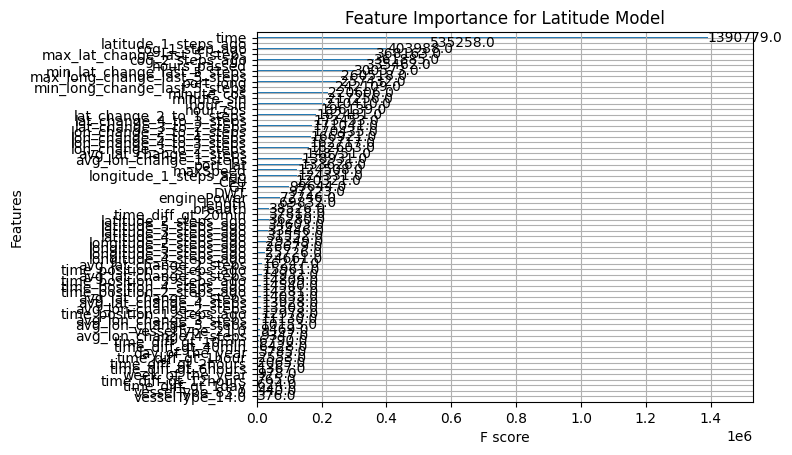

In [7]:
import matplotlib.pyplot as plt
import xgboost as xgb


# Plot feature importance for the Latitude model
plt.figure(figsize=(10, 30))
xgb.plot_importance(xgb_regressor, importance_type='weight', title="Feature Importance for Latitude Model")
plt.show()

In [ ]:
import joblib

joblib.dump(xgb_regressor, 'cog_model.pkl')



['cog_model.pkl']